In [1]:
!pip install torch torchvision transformers faiss-cpu datasets matplotlib scikit-learn pillow tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 27.7 MB/s eta 0:00:00


In [2]:
import os, numpy as np, torch, faiss, pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [24]:
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '300'
dataset = load_dataset("ashraq/fashion-product-images-small", split="train")
df = pd.DataFrame(dataset)
df = df[['id','articleType','gender','image']]
df = df.dropna()
print("Loaded dataset:", len(df))

os.makedirs("fashion_images", exist_ok=True)
paths, categories = [], []

for i, row in tqdm(df.iterrows(), total=len(df)):
    img = row['image']
    if not isinstance(img, Image.Image):
        continue
    path = f"fashion_images/{row['id']}.jpg"
    img.convert("RGB").save(path)
    paths.append(path)
    categories.append((row['articleType'], row['gender']))

df = pd.DataFrame({'path': paths, 'raw_category': [c[0] for c in categories], 'gender': [c[1] for c in categories]})
print("Images saved:", len(df))


Loaded dataset: 44072


100%|██████████| 44072/44072 [00:24<00:00, 1831.90it/s]


Images saved: 44072


In [25]:
print(df['raw_category'].value_counts().head(30))

raw_category
Tshirts                  7065
Shirts                   3212
Casual Shoes             2845
Watches                  2542
Sports Shoes             2016
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   928
Flip Flops                914
Sandals                   895
Briefs                    847
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     603
Jeans                     602
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Track Pants               304
Clutches                  288
Name: count, dtype: int64


In [38]:
mapping = {
    # Tops
    'Tshirts':'tops', 'Shirts':'tops', 'Tops':'tops', 'Kurtas':'tops',
    'Sweatshirts':'tops', 'Sweaters':'tops', 'Jackets':'tops', 'Blazers':'tops',
    'Tunics':'tops', 'Shrug':'tops', 'Nehru Jackets':'tops',

    # Bottoms
    'Jeans':'bottoms', 'Trousers':'bottoms', 'Shorts':'bottoms', 'Skirts':'bottoms',
    'Track Pants':'bottoms', 'Leggings':'bottoms', 'Capris':'bottoms',
    'Briefs':'bottoms', 'Boxers':'bottoms', 'Swimwear':'bottoms',

    # Dresses
    'Dresses':'dresses', 'Sarees':'dresses', 'Kurta Sets':'dresses',
    'Gowns':'dresses', 'Jumpsuit':'dresses', 'Rompers':'dresses',

    # Shoes
    'Casual Shoes':'shoes', 'Sports Shoes':'shoes', 'Heels':'shoes',
    'Flip Flops':'shoes', 'Sandals':'shoes', 'Flats':'shoes',
    'Formal Shoes':'shoes', 'Shoes':'shoes', 'Boots':'shoes',

    # Accessories
    'Watches':'accessories', 'Handbags':'accessories', 'Sunglasses':'accessories',
    'Wallets':'accessories', 'Belts':'accessories', 'Backpacks':'accessories',
    'Earrings':'accessories', 'Clutches':'accessories', 'Jewellery':'accessories',
    'Scarves':'accessories', 'Ties':'accessories', 'Socks':'accessories',
    'Caps':'accessories', 'Hats':'accessories', 'Beanies':'accessories',
    'Necklace and Chains':'accessories', 'Bracelet':'accessories',
    'Ring':'accessories', 'Pendant':'accessories',

    # Headwear
    'Caps':'headwear', 'Hats':'headwear', 'Beanies':'headwear',
}

df['category'] = df['raw_category'].map(mapping)
df = df[df['category'].notna()].reset_index(drop=True)

df = df.groupby('category', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42)
).reset_index(drop=True)

print(df['category'].value_counts())
print("Total:", len(df))


category
accessories    3000
bottoms        3000
tops           3000
shoes          3000
dresses        1013
headwear        283
Name: count, dtype: int64
Total: 13296


/tmp/ipykernel_4370/3209944363.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('category', group_keys=False).apply(


In [39]:
model_name = "openai/clip-vit-large-patch14"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
print("CLIP model loaded!")


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP model loaded!


In [37]:
def get_embedding(path: str) -> np.ndarray:
    """Get CLIP image embedding for a given image path."""
    try:
        img = Image.open(path).convert("RGB")
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            emb = model.get_image_features(**inputs)
        emb = emb / emb.norm(p=2)
        return emb.cpu().numpy().flatten()
    except Exception:
        return np.zeros(768)

print("Extracting embeddings...")
embeddings = np.array([get_embedding(p) for p in tqdm(df['path'])], dtype=np.float32)
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
print("FAISS index ready.")


Extracting embeddings...


100%|██████████| 15175/15175 [19:26<00:00, 13.01it/s]

FAISS index ready.


In [12]:
from skimage.morphology import skeletonize
from skimage import img_as_ubyte
import cv2

def show_preprocessing(img_path: str) -> None:
    """Show full CV preprocessing pipeline for a clothing image."""
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Otsu threshold
    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological Opening (removes noise) and Closing (fills holes)
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, kernel, iterations=2)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Boundary extraction
    eroded = cv2.erode(closed, kernel, iterations=1)
    boundary = cv2.subtract(closed, eroded)

    # Skeletonization
    binary_bool = closed > 0
    skeleton = img_as_ubyte(skeletonize(binary_bool))

    # Contours + Convex Hull on original
    contour_img = img_rgb.copy()
    hull_img = img_rgb.copy()
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(contour_img, [c], -1, (0, 255, 0), 2)
        hull = cv2.convexHull(c)
        cv2.drawContours(hull_img, [hull], -1, (255, 0, 0), 2)

    # GrabCut segmentation
    mask_gc = np.zeros(img_bgr.shape[:2], np.uint8)
    h, w = img_bgr.shape[:2]
    rect = (10, 10, w - 20, h - 20)
    cv2.grabCut(img_bgr, mask_gc, rect, np.zeros((1,65),np.float64), np.zeros((1,65),np.float64), 5, cv2.GC_INIT_WITH_RECT)
    grab_mask = np.where((mask_gc == 2) | (mask_gc == 0), 0, 1).astype('uint8')
    grabcut = img_rgb * grab_mask[:, :, np.newaxis]

    # Plot all steps
    steps = [
        (img_rgb,      "Original"),
        (gray,         "Grayscale",      "gray"),
        (otsu,         "Otsu Threshold", "gray"),
        (opened,       "Opening",        "gray"),
        (closed,       "Closing",        "gray"),
        (boundary,     "Boundary",       "gray"),
        (skeleton,     "Skeleton",       "gray"),
        (contour_img,  "Contours"),
        (hull_img,     "Convex Hull"),
        (grabcut,      "GrabCut"),
    ]

    plt.figure(figsize=(20, 4))
    for i, step in enumerate(steps):
        plt.subplot(1, len(steps), i + 1)
        cmap = step[2] if len(step) == 3 else None
        plt.imshow(step[0], cmap=cmap)
        plt.title(step[1], fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [13]:
opposites = {
    "tops":        ["bottoms", "shoes", "accessories"],
    "bottoms":     ["tops", "shoes", "accessories"],
    "shoes":       ["tops", "bottoms", "accessories"],
    "accessories": ["tops", "bottoms", "shoes"],
    "dresses":     ["shoes", "accessories"],
    "headwear":    ["tops", "bottoms", "shoes", "accessories"]
}

CLIP_LABELS = [
    "top or shirt", "pants or skirt or shorts", "dress",
    "shoes or footwear", "bag or watch or accessory", "cap or hat or headwear"
]
LABEL_TO_CAT = ["tops", "bottoms", "dresses", "shoes", "accessories", "headwear"]

GENDER_LABELS = ["mens clothing", "womens clothing", "unisex clothing"]
GENDER_MAP = ["Men", "Women", "Unisex"]

def predict_gender(img_path: str) -> str:
    """Predict gender category of clothing using CLIP."""
    img = Image.open(img_path).convert("RGB")
    inputs = processor(text=GENDER_LABELS, images=img, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)[0]
    return GENDER_MAP[probs.argmax().item()]

def predict_category(img_path: str) -> str:
    """Predict outfit category of an image using CLIP text-image matching."""
    img = Image.open(img_path).convert("RGB")
    inputs = processor(text=CLIP_LABELS, images=img, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)[0]
    return LABEL_TO_CAT[probs.argmax().item()]


In [14]:
def show_grid(image_paths: list, titles: list, cols: int = 5, figsize: tuple = (15, 5)):
    """Display images in a grid with titles."""
    rows = (len(image_paths) + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, (path, title) in enumerate(zip(image_paths, titles)):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(path).convert("RGB")
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [15]:
def recommend_outfit_from_image(img_path: str) -> None:
    """Recommend 1 outfit item per complementary category for the uploaded image."""
    print("\nDetecting category...")
    query_cat = predict_category(img_path)
    print("Detected Category →", query_cat)

    complementary_cats = opposites.get(query_cat, [])
    if not complementary_cats:
        print("No complementary categories found.")
        return

    q_emb = get_embedding(img_path).reshape(1, -1).astype(np.float32)
    faiss.normalize_L2(q_emb)
    sims, idxs = index.search(q_emb, len(df))

    filtered = df.iloc[idxs[0]].copy()
    filtered['similarity'] = sims[0]
    filtered = filtered[filtered['category'].isin(complementary_cats)]
    predicted_gender = predict_gender(img_path)
    filtered = filtered[filtered['gender'].isin([predicted_gender, "Unisex"])]

    # Pick 1 randomly from top 5 per category (gives variety across different uploads)
    recommendations = []
    for cat in complementary_cats:
        candidates = filtered[filtered['category'] == cat].head(5)
        if not candidates.empty:
            recommendations.append(candidates.sample(1, random_state=hash(img_path) % 100).iloc[0])

    rec_df = pd.DataFrame(recommendations)
    print(f"Recommending: {rec_df['category'].tolist()}")
    show_grid(
        [img_path] + rec_df['path'].tolist(),
        ["Uploaded"] + rec_df['category'].tolist(),
        cols=len(rec_df) + 1
    )


In [16]:
def upload_and_match() -> None:
    """Upload an image and get outfit recommendations."""
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return
    user_img = list(uploaded.keys())[0]
    show_preprocessing(user_img)
    recommend_outfit_from_image(user_img)


Saving 1532.jpg to 1532.jpg


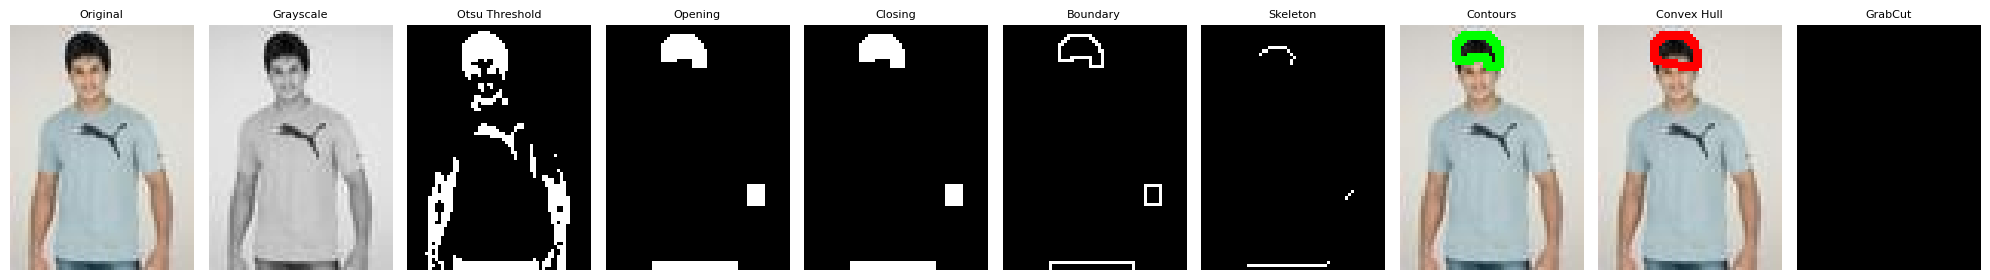


Detecting category...
Detected Category → tops
Recommending: ['bottoms', 'shoes', 'accessories']


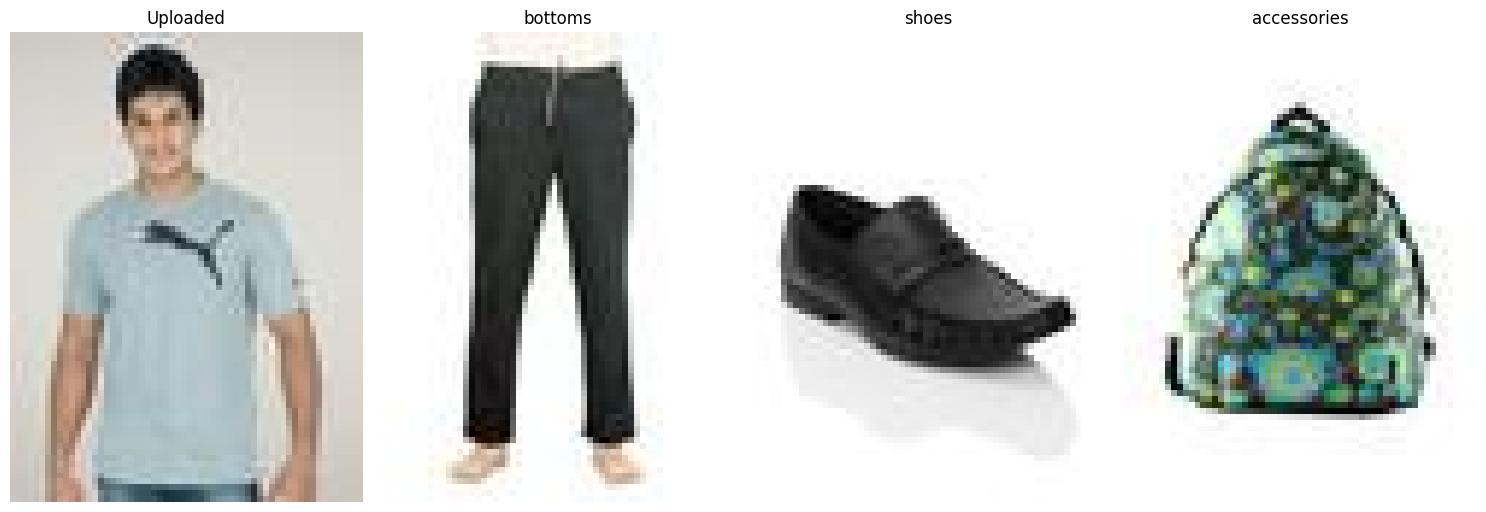

In [42]:
upload_and_match()